# Project: Predicting Startup Profits

	1. Do transformations for getting better predictions of profit and make a table containing R^2 value for each prepared model.
	2. Do proper exploratory Data Analysis.
	3. Upload the Code in the github
	4. Share the HTML jupyter notebook in the mail.
	5. Use notion.io for process tracking and timeline.


---


Dataset Descriptions - 

R&D Spend -- Research and devolop spend in the past few years
Administration -- spend on administration in the past few years
Marketing Spend -- spend on Marketing in the past few years
State -- states from which data is collected
Profit  -- profit of each state in the past few years

**This project aims to build a machine learning model to predict the profit of a startup based on its R&D, Administration, and Marketing spends, as well as its location.**


---




**1. Project Setup and Data Loading**

In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [77]:
# Data file path
path = ('D:/Works/Top Mentor/Python/Assignments/Multi Linear Regression - Assignment -2/3. Multi Linear Regression/50_Startups.csv')

In [78]:
data = pd.read_csv(path)
data.head(4)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99


**2. Comprehensive Exploratory Data Analysis (EDA)**

In [79]:
data.shape

(50, 5)

In [80]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB


In [81]:
data.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [82]:
# Checking correlation for only numeric columns

data.corr(numeric_only=True)

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


In [83]:
data['State']

0       New York
1     California
2        Florida
3       New York
4        Florida
5       New York
6     California
7        Florida
8       New York
9     California
10       Florida
11    California
12       Florida
13    California
14       Florida
15      New York
16    California
17      New York
18       Florida
19      New York
20    California
21      New York
22       Florida
23       Florida
24      New York
25    California
26       Florida
27      New York
28       Florida
29      New York
30       Florida
31      New York
32    California
33       Florida
34    California
35      New York
36       Florida
37    California
38      New York
39    California
40    California
41       Florida
42    California
43      New York
44    California
45      New York
46       Florida
47    California
48      New York
49    California
Name: State, dtype: str

In [84]:
data['State'].unique()

<StringArray>
['New York', 'California', 'Florida']
Length: 3, dtype: str

In [85]:
# 1. Handle Missing Data

print("Missing value per column: ")
data.isnull().sum()

Missing value per column: 


R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

array([[<Axes: title={'center': 'R&D Spend'}>,
        <Axes: title={'center': 'Administration'}>],
       [<Axes: title={'center': 'Marketing Spend'}>,
        <Axes: title={'center': 'Profit'}>]], dtype=object)

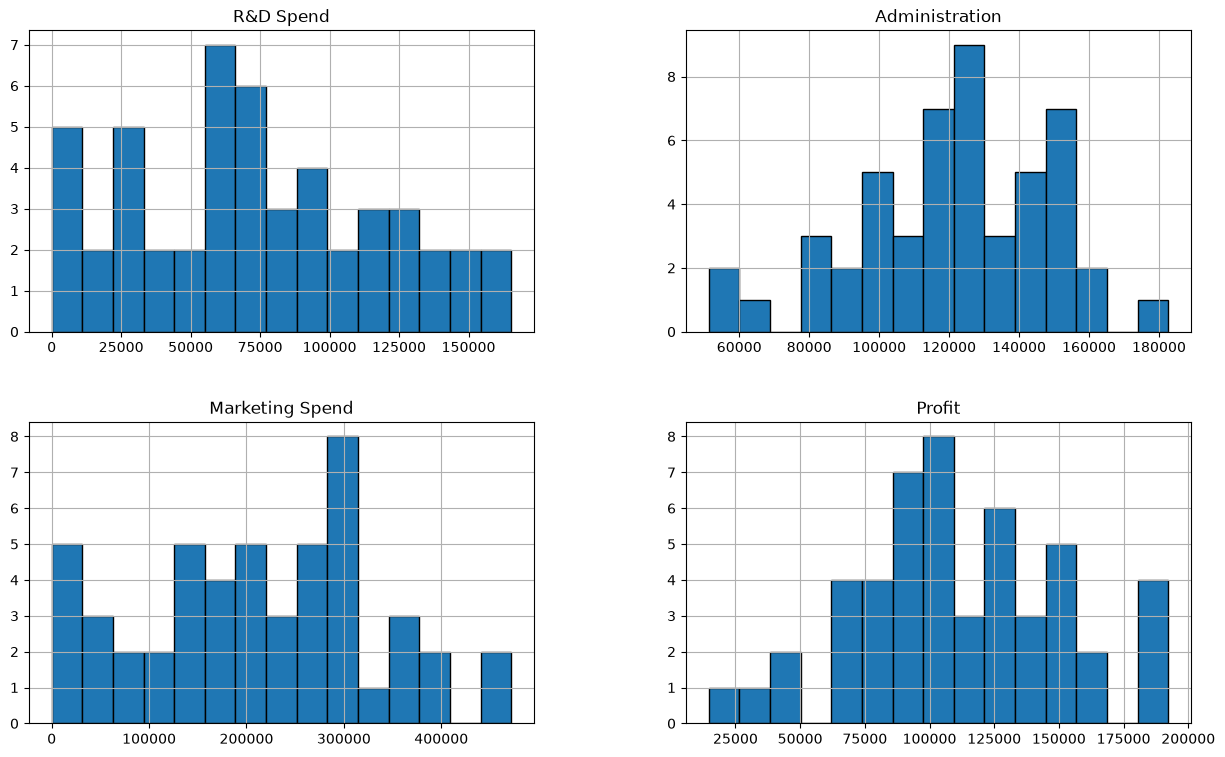

In [86]:
# 2. Exploratory Data Analysis

data.hist(figsize=(15, 9), bins=15, edgecolor='black')

In [87]:
corr = data.corr(numeric_only=True)
corr

,R&D Spend,Administration,Marketing Spend,Profit
R&D Spend,1.000000,0.241955,0.724248,0.972900
Administration,0.241955,1.000000,-0.032154,0.200717
Marketing Spend,0.724248,-0.032154,1.000000,0.747766
Profit,0.972900,0.200717,0.747766,1.000000


<Axes: >

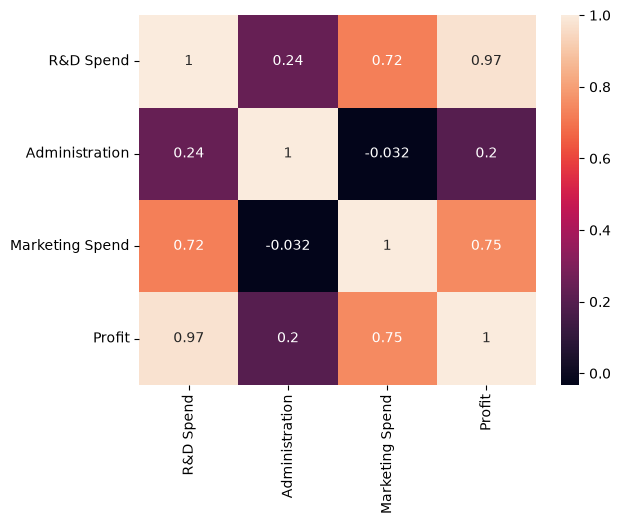

In [88]:
sns.heatmap(corr, annot=True)

In [89]:
data["State"].unique()

<StringArray>
['New York', 'California', 'Florida']
Length: 3, dtype: str

In [90]:
# Mapping the string data (State) to numerical for error free calculations
# Method 2: Drop first category to avoid dummy variable trap

# Method 2: Drop first category to avoid dummy variable trap
data = pd.get_dummies(data, columns=['State'], dtype=int)


print(data.head())


   R&D Spend  Administration  Marketing Spend     Profit  State_California  \
0  165349.20       136897.80        471784.10  192261.83                 0   
1  162597.70       151377.59        443898.53  191792.06                 1   
2  153441.51       101145.55        407934.54  191050.39                 0   
3  144372.41       118671.85        383199.62  182901.99                 0   
4  142107.34        91391.77        366168.42  166187.94                 0   

   State_Florida  State_New York  
0              0               1  
1              0               0  
2              1               0  
3              0               1  
4              1               0  


In [91]:
# Converting the data to list

print("New columns:", data.columns.tolist())

New columns: ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit', 'State_California', 'State_Florida', 'State_New York']


In [92]:
data.head(3)

,R&D Spend,Administration,Marketing Spend,Profit,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,0,1
1,162597.70,151377.59,443898.53,191792.06,1,0,0
2,153441.51,101145.55,407934.54,191050.39,0,1,0


In [123]:
x = data.drop('Profit', axis=1)
x.head(3)

,R&D Spend,Administration,Marketing Spend,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,0,0,1
1,162597.70,151377.59,443898.53,1,0,0
2,153441.51,101145.55,407934.54,0,1,0


In [124]:
y = data.iloc[:, 3]
y.head(2)

0    192261.83
1    191792.06
Name: Profit, dtype: float64

**Training the dataset**

In [95]:
# Importing library for training the dataset

from sklearn.model_selection import train_test_split

In [125]:
data.head(3)

,R&D Spend,Administration,Marketing Spend,Profit,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,0,1
1,162597.70,151377.59,443898.53,191792.06,1,0,0
2,153441.51,101145.55,407934.54,191050.39,0,1,0


In [126]:
# Training the data model

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2)

In [127]:
# Shape of training dataset

x_train.shape, y_train.shape

((40, 6), (40,))

In [128]:
# Shape of test dataset

x_test.shape, y_test.shape

((10, 6), (10,))

**Important Library while using linear reg**

- StandardScaler is indeed a CRUCIAL tool in machine learning because:
- Removes Scale Bias: Prevents features with larger numbers from dominating
- Improves Performance: Helps algorithms converge faster
- Enables Comparison: Makes coefficients interpretable

In [129]:
from sklearn.preprocessing import StandardScaler 

In [130]:
# Creating a scaler obj

scaler = StandardScaler()

In [131]:
x_train_scaled = scaler.fit_transform(x_train)

In [132]:
x_test_scaled = scaler.transform(x_test)

In [133]:
# Importing the model to train dataset

from sklearn.linear_model import LinearRegression

In [134]:
model = LinearRegression()
print(model)

LinearRegression()


In [135]:
print("Model Training: ")
model.fit(x_train_scaled, y_train)

Model Training: 


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[36389.32,-2481.63, 1147.7 ,-1192.41, 64.07, 1100.43]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.079e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[9.19,7.93,6.91,5.97,3.02,0. ]"


**Predicting the value based on model**

In [136]:
pred = model.predict(x_test_scaled)

**Importing below library for calculating mean error, Model Validation**

In [137]:
# Importing r2_score to check the accuracy of the model

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

**Model Validation: Checking the accuracy of the predicted values by trained model**

In [138]:
acc = r2_score(y_test, pred)*100
print(f"Accuracy of the model is r2_score:{acc: .2f}%")

Accuracy of the model is r2_score: 91.95%


In [139]:
# Error percentage

error_percentage = round(100-acc,2)
print(f"Error Percentage of Model: {error_percentage}")

Error Percentage of Model: 8.05


**Now comparing the feature importance**

In [140]:
feature_names = x.columns
feature_names

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State_California',
       'State_Florida', 'State_New York'],
      dtype='str')

In [142]:
for feature, coef in zip(feature_names, coefficients):
    print(f"  {feature}: {coef:.4f}")

  R&D Spend: 36389.3236
  Administration: -2481.6286
  Marketing Spend: 1147.7029
  State_California: -1192.4134
  State_Florida: 64.0729
  State_New York: 1100.4290


In [143]:
# Compare Actual vs Predicted
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': pred,
    'Difference': y_test - pred})
comparison_df.head(3)

,Actual,Predicted,Difference
13,134307.35,124439.387485,9867.962515
1,191792.06,183770.324741,8021.735259
6,156122.51,157702.091541,-1579.581541


<Axes: xlabel='R&D Spend'>

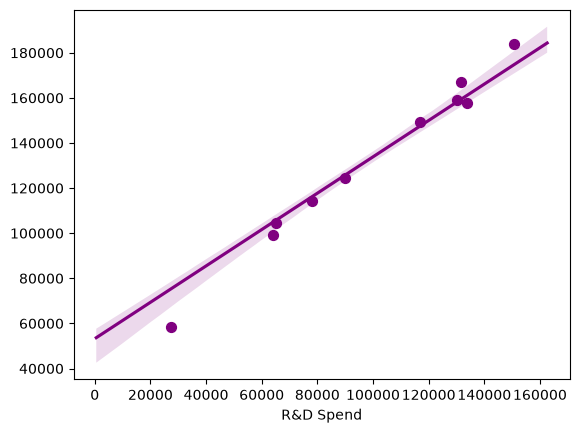

In [144]:
sns.regplot(x = x_test['R&D Spend'], y = pred, color='Purple', x_bins= 20)

**Saving and Loading the model for future use**

In [145]:
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(model, 'model.pkl')
print(f"Model: {model} and Scalar: {scaler} saved for future use!")

Model: LinearRegression() and Scalar: StandardScaler() saved for future use!


In [146]:
loaded_model = joblib.load('model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

**Testing the saved model on new data**

In [147]:
new_data = [[165349.20, 136897.80, 471784.10, 0, 1, 5]]
new_data_scaled = loaded_scaler.transform(new_data)
prediction = loaded_model.predict(new_data_scaled)

e:\Python Docs\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [148]:

print(f"Predicted Profit: ${prediction[0]:,.2f}")

Predicted Profit: $202,140.34
